In [2]:
from pathlib import Path
from typing import Tuple, List
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
class Capability:
    def __init__(self, line, parent):
        #print(line)
        _, boundsOffset, _, boundsLength, _, boundsVirtualBase, _, capPerms   = line.split()
        self.boundsOffset = int(boundsOffset, 16)
        self.boundsLength = int(boundsLength, 16)
        self.boundsVirtBase = int(boundsVirtualBase, 16)
        self.capPerms = int(capPerms, 2)
        self.parent = parent
        parent.child = self

    def capKey(self):
        return (self.boundsVirtBase, self.boundsLength)
    
    def __eq__(self, other):
        return self.boundsOffset == other.boundsOffset and self.boundsLength == other.boundsLength and self.boundsVirtBase == other.boundsVirtBase and self.capPerms == other.capPerms

    def __hash__(self):
        return hash((self.boundsOffset, self.boundsLength, self.boundsVirtBase, self.capPerms))
    
    def __repr__(self):
        return f"Cap virtBase {self.boundsVirtBase} length {self.boundsLength} offset {self.boundsOffset}"

class ReportAccessLog:
    def __init__(self, line):
        #44200 Prefetcher logReportAccess level 1 addr 00000000c0007648 pcHash c0000260 hitMiss 1 boundsOffset 0000000000000008 boundsLength 0000000000002f30 boundsVirtBase 00000000c0007640 capPerms 0000000000001111000111111010111

        #print(line.split())
        clock_time,_, _, _, level, _, addr, _, pcHash, _, isMiss, _, boundsOffset, _, boundsLength, _, boundsVirtualBase, _, capPerms   = line.split()
        self.clock_time = int(clock_time)
        self.level = int(level)
        self.addr = int(addr, 16)
        self.pcHash = int(pcHash, 16)
        self.isMiss = int(isMiss)

        
        self.cap = Capability("boundsOffset"+line.partition("boundsOffset")[2], self)
    
class ReportDataArrivalCap:
    def __init__(self, line, parent):
        pre, _, cap = line.partition("boundsOffset")
        _, _, _, _, index, _, tag, _, addr = pre.split()
        self.index = int(index)
        self.tag = bool(int(tag))
        self.addr = int(addr, 16)
        if self.tag:
            self.cap = Capability("boundsOffset"+cap, parent)
        self.parent = parent
        parent.child = self

class ReportDataArrival:
    def __init__(self, line):
        clock_time,_, _, _, level, _, requestAddr, _, pcHash, _, wasMiss, _, wasPrefetch, _, boundsOffset, _, boundsLength, _, boundsVirtualBase, _, capPerms   = line.split()
        self.clock_time = int(clock_time)
        self.level = int(level)
        self.requestAddr = int(requestAddr, 16)
        self.pcHash = int(pcHash, 16)
        self.wasMiss = int(wasMiss)
        self.wasPrefetch = int(wasPrefetch)
        self.requestCap = Capability("boundsOffset"+line.partition("boundsOffset")[2], self)
        self.capabilites: List[ReportDataArrivalCap] = []

    def add_capability(self, line, parent_data_arrivals):
        capability = ReportDataArrivalCap(line, self)
        if capability.tag:
            self.capabilites.append(capability)
            parent_data_arrivals[capability.cap.capKey()] = capability.cap 

        return capability




def parse_log(input_file) -> Tuple[List[ReportAccessLog], List[ReportDataArrival], List[ReportAccessLog]]:
    recent_misses = set()
    parent_access = {} #(cap_virtual_base, cap_size, most recent ReportAccessLog)
    parent_data_arrivals = {} #(cap_virtual_base, cap_size, most recent ReportAccessLog)
    accesses = []
    data_arrivals = []
    access_misses = []

    with open(input_file, "r") as fp:
        while True:
            line = fp.readline()
            if not line:
                break

            if "logReportAccess" in line:
                reportAccess = ReportAccessLog(line)

                if reportAccess.isMiss:
                    recent_misses.add(reportAccess.addr)
                    access_misses.append(reportAccess)
                elif reportAccess.addr in recent_misses:
                    #Skip first hit access after miss
                    recent_misses.remove(reportAccess.addr)
                    continue

                accesses.append(reportAccess)
                parent_access[reportAccess.cap.capKey()] = reportAccess.cap

                if reportAccess.cap.capKey() in parent_data_arrivals:
                    parent = parent_data_arrivals[reportAccess.cap.capKey()]
                    reportAccess.parent = parent
                    parent.child = reportAccess
                    #parent.child = reportAccess
                    #print("found parent")

                # if reportAccess.cap.boundsLength == 40000:
                #         print("40000 arrival")
                #         print(reportAccess.cap.capKey())
                #print(reportAccess.cap.boundsLength)
            
            elif "logReportDataArrival" in line:
                data_arrival = ReportDataArrival(line)
                data_arrival.add_capability(fp.readline(), parent_data_arrivals)
                data_arrival.add_capability(fp.readline(), parent_data_arrivals)
                data_arrival.add_capability(fp.readline(), parent_data_arrivals)
                data_arrival.add_capability(fp.readline(), parent_data_arrivals)
                data_arrivals.append(data_arrival)

                if data_arrival.requestCap.capKey() in parent_access:
                    # if data_arrival.requestCap.boundsLength == 40000:
                    #     print("40000 arrival in arrival")
                    parent = parent_access[data_arrival.requestCap.capKey()]
                    data_arrival.parent = parent
                    parent.child = data_arrival
                    #parent.child = data_arrival
                    #print("found parent2")

                # if data_arrival.requestCap.boundsLength == 40000:
                #     print(data_arrival.requestCap.capKey())
                    


    print(f"access {len(accesses)} misses {len(access_misses)}")
    return accesses, data_arrivals, access_misses

In [ ]:
#input_file = Path("../simulations/adpcm_decode") / "sim_0.0" / "sim_stdout"
input_file = Path("../simulations/dijkstra") / "sim_0.0" / "sim_stdout"

accesses, data_arrivals, access_misses = parse_log(input_file)

access 46950 misses 335


In [44]:
def sort_by_count(d):
    return dict(sorted(d.items(), key=lambda item: item[1], reverse=True))

In [45]:
def set_dict_to_count(set_dict):
    return {k: len(v) for k,v in set_dict.items()}
def plot_count(count_dict: dict, xlabel, ylabel):
    df = pd.DataFrame(data = {"key": count_dict.keys(), "value": count_dict.values()})
    df = df.sort_values("key")
    df.plot(kind="bar", x="key", y="value", xlabel=xlabel, ylabel=ylabel)

In [46]:
pc_num_caps = defaultdict(int)
pc_num_caps_unique = defaultdict(set)
pc_num_address = defaultdict(int)
pc_offsets = defaultdict(int)
caps_offset = defaultdict(int)
num_offsets
pcs = set()

for i, data_arrival in enumerate(data_arrivals):
    pc_num_caps[data_arrival.pcHash, data_arrival.requestCap.capKey()] += 1
    pc_num_caps_unique[data_arrival.pcHash].add(data_arrival.requestCap.capKey())
    pc_offsets[data_arrival.pcHash, data_arrival.requestCap.boundsOffset] += 1
    pc_num_address[data_arrival.pcHash, data_arrival.requestAddr] += 1
    caps_offset[data_arrival.requestCap.boundsVirtBase, data_arrival.requestCap.boundsOffset] += 1
    pcs.add(data_arrival.pcHash)

    chain = [data_arrival.requestCap.boundsOffset]


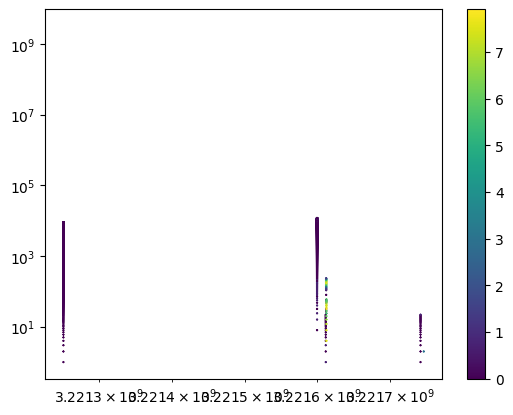

In [47]:
sc = plt.scatter(*zip(*caps_offset.keys()), c=np.log(list(caps_offset.values())), marker='x', s = 0.5)
plt.yscale('log')
plt.xscale('log')
plt.colorbar(sc)

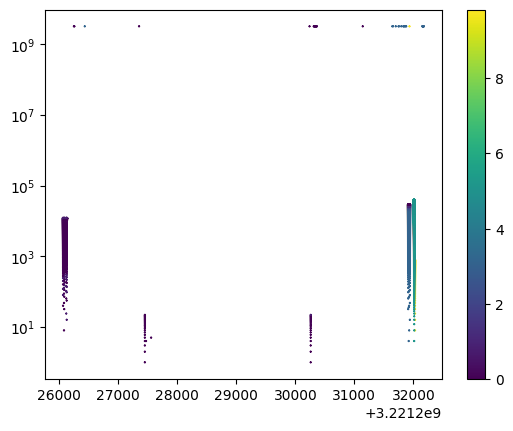

In [39]:
sc = plt.scatter(*zip(*pc_offsets.keys()), c=np.log(list(pc_offsets.values())), marker='x', s = 0.5)
plt.yscale('log')
plt.colorbar(sc)

In [7]:
set_dict_to_count(pc_num_caps_unique)

{3221226080: 1,
 3221226084: 1,
 3221226126: 1,
 3221226118: 1,
 3221226064: 1,
 3221226134: 1,
 3221226248: 1,
 3221226256: 1,
 3221226260: 1,
 3221226262: 1,
 3221231142: 1,
 3221227352: 1,
 3221227450: 1,
 3221227470: 1,
 3221227556: 1,
 3221230240: 1,
 3221226432: 1,
 3221226436: 1,
 3221230260: 1,
 3221230312: 1,
 3221230316: 1,
 3221230320: 1,
 3221230328: 1,
 3221230332: 1,
 3221230340: 1,
 3221230344: 1,
 3221230348: 1,
 3221230352: 1,
 3221230356: 1,
 3221230360: 1,
 3221230364: 1,
 3221230336: 1,
 3221230324: 1,
 3221231642: 1,
 3221231656: 1,
 3221231702: 1,
 3221231748: 1,
 3221231756: 1,
 3221231794: 1,
 3221231798: 1,
 3221231766: 1,
 3221231828: 1,
 3221231836: 1,
 3221231856: 1,
 3221231844: 1,
 3221231870: 1,
 3221231878: 1,
 3221231906: 1,
 3221231912: 1,
 3221231920: 1,
 3221231928: 1,
 3221231934: 1,
 3221231940: 1,
 3221232028: 1,
 3221232014: 1,
 3221232088: 1,
 3221231958: 1,
 3221231962: 1,
 3221232152: 1,
 3221232154: 1,
 3221232156: 1,
 3221232158: 1,
 3221232

In [8]:
len(sort_by_count(pc_num_caps))

71

In [9]:
[i[1] / 8 for i in pc_num_address.keys()]

[402662175.0,
 402662178.0,
 402662176.0,
 402662177.0,
 402662180.0,
 402662183.0,
 402662174.0,
 402662182.0,
 402662181.0,
 402662179.0,
 402662185.0,
 402662188.0,
 402662187.0,
 402662186.0,
 402662184.0,
 402662190.0,
 402662191.0,
 402662189.0,
 402662193.0,
 402662192.0,
 402662195.0,
 402662198.0,
 402662197.0,
 402662196.0,
 402662194.0,
 402662199.0,
 402662203.0,
 402662200.0,
 402662202.0,
 402662201.0,
 402662205.0,
 402662207.0,
 402662206.0,
 402662204.0,
 402662208.0,
 402662210.0,
 402662213.0,
 402662212.0,
 402662211.0,
 402662215.0,
 402662209.0,
 402662214.0,
 402662218.0,
 402662217.0,
 402662216.0,
 402662220.0,
 402662223.0,
 402662222.0,
 402662221.0,
 402662219.0,
 402662225.0,
 402662228.0,
 402662227.0,
 402662226.0,
 402662224.0,
 402662230.0,
 402662231.0,
 402662229.0,
 402662233.0,
 402662232.0,
 402662235.0,
 402662238.0,
 402662237.0,
 402662236.0,
 402662234.0,
 402662239.0,
 402662243.0,
 402662242.0,
 402662241.0,
 402662245.0,
 402662240.0,
 40266

In [10]:
hex(3221311488)

'0xc0015000'

In [11]:
sort_by_count(pc_num_address)

{(3221232088, 3221311488): 18384,
 (3221232028, 3221472272): 16816,
 (3221232028, 3221472416): 16815,
 (3221232028, 3221472144): 16813,
 (3221232028, 3221472032): 16807,
 (3221232028, 3221471952): 16806,
 (3221232028, 3221472424): 16803,
 (3221232028, 3221472440): 16802,
 (3221232028, 3221472528): 16802,
 (3221232028, 3221472448): 16800,
 (3221232028, 3221472296): 16798,
 (3221232028, 3221472152): 16797,
 (3221232028, 3221472496): 16797,
 (3221232028, 3221472368): 16794,
 (3221232028, 3221472024): 16793,
 (3221232028, 3221472096): 16793,
 (3221232028, 3221472288): 16792,
 (3221232028, 3221471760): 16789,
 (3221232028, 3221472264): 16789,
 (3221232028, 3221471784): 16788,
 (3221232028, 3221472056): 16787,
 (3221232028, 3221472464): 16787,
 (3221232028, 3221471944): 16786,
 (3221232028, 3221472112): 16786,
 (3221232028, 3221472208): 16786,
 (3221232028, 3221472104): 16784,
 (3221232028, 3221472176): 16783,
 (3221232028, 3221472432): 16783,
 (3221232028, 3221472064): 16781,
 (3221232028, 

In [12]:
pcs

{3221226064,
 3221226080,
 3221226084,
 3221226118,
 3221226126,
 3221226134,
 3221226248,
 3221226256,
 3221226260,
 3221226262,
 3221226432,
 3221226436,
 3221227352,
 3221227450,
 3221227470,
 3221227556,
 3221230240,
 3221230260,
 3221230312,
 3221230316,
 3221230320,
 3221230324,
 3221230328,
 3221230332,
 3221230336,
 3221230340,
 3221230344,
 3221230348,
 3221230352,
 3221230356,
 3221230360,
 3221230364,
 3221231142,
 3221231642,
 3221231656,
 3221231702,
 3221231748,
 3221231756,
 3221231766,
 3221231794,
 3221231798,
 3221231828,
 3221231836,
 3221231844,
 3221231856,
 3221231870,
 3221231878,
 3221231906,
 3221231912,
 3221231920,
 3221231928,
 3221231934,
 3221231940,
 3221231958,
 3221231962,
 3221232014,
 3221232028,
 3221232088,
 3221232152,
 3221232154,
 3221232156,
 3221232158,
 3221232160,
 3221232162,
 3221232164,
 3221232166,
 3221232168,
 3221232170,
 3221232172,
 3221232174,
 3221232176}

In [33]:
size_miss = defaultdict(int)
size_total = defaultdict(int)
virtual_addr = defaultdict(int)
virt_size_pair = defaultdict(int)
size_virt_set = defaultdict(set)

miss_caps = defaultdict(int)

seen_before_request_cap = set()
seen_before_cap_cacheline = set()

how_many_cache_lines = defaultdict(set)

size_access = defaultdict(int)

offsets_access_size = defaultdict(set)
offsets_seen_size = defaultdict(set)

for i, data_arrival in enumerate(data_arrivals):

    # if data_arrival.requestCap in seen_before_request_cap:
    #     #print(data_arrival.requestCap.boundsVirtBase)
    #     #print("Same cache line accessed")
    #     continue
    # #print(data_arrival.wasMiss)

    # seen_before_request_cap.add(data_arrival.requestCap)

    #print(i)
    size_access[data_arrival.requestCap.boundsLength] += 1
    offsets_access_size[data_arrival.requestCap.boundsLength].add(data_arrival.requestCap.boundsOffset)

    if data_arrival.wasMiss:
        size_miss[data_arrival.requestCap.boundsLength] += 1
        miss_caps[data_arrival.requestCap] += 1
        #print("miss")


    for capLine in data_arrival.capabilites:
        # if capLine.cap in seen_before_cap_cacheline:
        #     # print("same cap in multiple cache lines")
        #     # #print(data_arrival.requestAddr)
        #     # print(capLine.addr)
        # else:
        seen_before_cap_cacheline.add(capLine.cap)

        how_many_cache_lines[capLine.cap].add(data_arrival.requestCap)
        
        
        size_total[capLine.cap.boundsLength] += 1
        virtual_addr[capLine.cap.boundsVirtBase] += 1
        virt_size_pair[capLine.cap.boundsVirtBase, capLine.cap.boundsLength] += 1
        size_virt_set[capLine.cap.boundsLength].add(capLine.cap.boundsVirtBase)
        offsets_seen_size[capLine.cap.boundsLength].add(capLine.cap.boundsOffset)

In [34]:
i = 0
for data_arrival in data_arrivals:
    if hasattr(data_arrival.parent.parent, 'parent'):
        print(data_arrival.parent.parent)
        print(f"parent: {data_arrival.parent.parent.parent.parent}       child: {data_arrival.requestCap}")
        i += 1
    if i > 1:
        break

parent: <__main__.ReportDataArrival object at 0x7f67abb2e550>       child: Cap virtBase 3221251344 length 16 offset 0
parent: <__main__.ReportDataArrival object at 0x7f67abb2e550>       child: Cap virtBase 3221251328 length 16 offset 0


In [35]:
len(seen_before_cap_cacheline)

952

In [61]:
def backwards_analysis(data_arrivals, depth, miss_only: bool):
    backwards_dict = defaultdict(int)
    pc_chain = defaultdict(int)
    pc_chain_sets = defaultdict(set)
    for data_arrival in data_arrivals:
        if miss_only and not data_arrival.wasMiss:
            continue

        chain = []
        chain.append(data_arrival.requestCap.capKey())
        top_pc = None
        
        head = data_arrival

        met_depth = True

        for i in range(depth-1):
            if hasattr(head.parent.parent, 'parent'):
                chain.append(head.parent.parent.parent.capKey())
                head = head.parent.parent
                top_pc = head.pcHash
            else:
                met_depth = False

        if met_depth:
            backwards_dict[tuple(chain)] += 1
            pc_chain[top_pc, tuple(chain)] += 1
            pc_chain_sets[top_pc].add(tuple(chain))
    return backwards_dict, pc_chain,pc_chain_sets

In [69]:
back_dict, pc_chain_dict, pc_chain_set_dict = backwards_analysis(data_arrivals, 3, False)

In [70]:
len(back_dict)

13

In [71]:
len(pc_chain_dict)

19

In [72]:
set_dict_to_count(pc_chain_set_dict)

{3221226256: 2,
 3221231142: 1,
 3221226432: 1,
 3221230260: 1,
 3221231794: 1,
 3221231756: 1,
 3221231828: 3,
 3221231906: 1,
 3221231844: 3,
 3221231934: 1,
 3221231912: 1,
 3221231920: 1,
 3221231928: 1,
 3221231940: 1}

In [37]:
x = 0
for i, data_arrival in enumerate(data_arrivals):
    x += 1

In [38]:
total_seen_chains = defaultdict(int)
for i, data_arrival in enumerate(data_arrivals):
    #if i > 100000: break
    for capLine in data_arrival.capabilites:
        #print(data_arrival.requestCap == capLine.cap)
        if data_arrival.requestCap.capKey == (3221254656, 269824):
            print("wow!!1")

        if capLine.cap.capKey() == (3221674560, 16) and data_arrival.requestCap.capKey() == (3221254656, 269824):
            print("here!!")
        chain = [capLine.cap.capKey(), data_arrival.requestCap.capKey()]
        #print(chain)
        met_depth = True
        if hasattr(data_arrival.parent.parent, 'parent'):
            chain.append(data_arrival.parent.parent.parent.capKey())
            #print(data_arrival.requestCap == data_arrival.parent.parent.parent)
        else:
            met_depth = False
        if met_depth:
            total_seen_chains[tuple(chain)] += 1

In [13]:
sort_by_count(total_seen_chains)

NameError: name 'sort_by_count' is not defined

In [156]:
total_seen_chains[((3221254656, 269824), (3221254656, 269824), (3221674560, 16))]

0

In [155]:
backwards_miss[((3221254656, 269824), (3221254656, 269824), (3221674560, 16))]

4421

In [152]:
sort_by_count(backwards_miss)

{((3221254656, 269824), (3221254656, 269824), (3221674560, 16)): 4421,
 ((3221254656, 269824), (3221254656, 269824), (0, 18446744073709551615)): 4215,
 ((3221254656, 269824), (3221254656, 269824), (3221674592, 16)): 2279,
 ((3221254656, 269824), (3221254656, 269824), (3221674512, 16)): 1801,
 ((3221254656, 269824), (3221254656, 269824), (3221674528, 16)): 1532,
 ((3221254656, 269824), (3221254656, 269824), (3221674576, 8)): 1089,
 ((3221254656, 269824), (3221254656, 269824), (3221673424, 16)): 802,
 ((3221254656, 269824), (3221254656, 269824), (3221673448, 8)): 434,
 ((3221254656, 269824), (3221254656, 269824), (3221673408, 16)): 359,
 ((3221254656, 269824), (3221254656, 269824), (3221674428, 4)): 194,
 ((0, 3225419776), (0, 3225419776), (0, 3225419776)): 145,
 ((3221254656, 269824), (3221254656, 269824), (3221673520, 16)): 29,
 ((3221254656, 269824), (3221254656, 269824), (3221674440, 8)): 27,
 ((3221674512, 16), (3221674512, 16), (0, 3225419776)): 24,
 ((3221254656, 269824), (3221254

In [95]:
backwards_miss = backwards_analysis(data_arrivals, 3, True)

In [112]:
sum(backwards_miss.values())

17502

In [96]:
backwards_total = backwards_analysis(data_arrivals, 3, False)

In [102]:
sort_by_count({k: (v, backwards_total[k]) for k,v in backwards_miss.items()})

{((3221254656, 269824), (3221254656, 269824), (3221674560, 16)): (4421,
  111070),
 ((3221254656, 269824),
  (3221254656, 269824),
  (0, 18446744073709551615)): (4215, 33720),
 ((3221254656, 269824), (3221254656, 269824), (3221674592, 16)): (2279, 36118),
 ((3221254656, 269824), (3221254656, 269824), (3221674512, 16)): (1801, 35770),
 ((3221254656, 269824), (3221254656, 269824), (3221674528, 16)): (1532, 25111),
 ((3221254656, 269824), (3221254656, 269824), (3221674576, 8)): (1089, 14753),
 ((3221254656, 269824), (3221254656, 269824), (3221673424, 16)): (802, 906183),
 ((3221254656, 269824), (3221254656, 269824), (3221673448, 8)): (434, 186249),
 ((3221254656, 269824), (3221254656, 269824), (3221673408, 16)): (359, 574257),
 ((3221254656, 269824), (3221254656, 269824), (3221674428, 4)): (194, 2184),
 ((0, 3225419776), (0, 3225419776), (0, 3225419776)): (145, 4198773),
 ((3221254656, 269824), (3221254656, 269824), (3221673520, 16)): (29, 2976),
 ((3221254656, 269824), (3221254656, 26982

In [133]:
df = pd.DataFrame({"miss":pd.Series(backwards_miss), "total": pd.Series(backwards_total), "seen": pd.Series(total_seen_chains)})
df["percentage"] = df["miss"]/df["total"]
#df.sort_values("miss", ascending=False)
df

miss  \
(0, 3225419776)           (0, 3225419776)  (0, 3225419776)     145.0   
                                           (3221670176, 4096)    NaN   
                                           (3221673536, 16)      6.0   
                          (3221673536, 16) (3221673536, 16)      NaN   
(0, 36893488147419103231) (0, 3225419776)  (0, 3225419776)       NaN   
...                                                              ...   
(3221674576, 8)           (3221674576, 8)  (0, 3225419776)      16.0   
(3221674584, 8)           (0, 3225419776)  (0, 3225419776)       NaN   
                          (3221674584, 8)  (0, 3225419776)       NaN   
(3221674592, 16)          (0, 3225419776)  (0, 3225419776)       NaN   
                          (3221674592, 16) (0, 3225419776)       5.0   

                                                                   total  \
(0, 3225419776)           (0, 3225419776)  (0, 3225419776)     4198773.0   
                                           (3221670176, 4096)       44.0   
                                           (3221673536, 16)    1957588.0   
                          (3221673536, 16) (3221673536, 16)          NaN   
(0, 36893488147419103231) (0, 3225419776)  (0, 3225419776)           NaN   
...                                                                  ...   
(3221674576, 8)           (3221674576, 8)  (0, 3225419776)      198213.0   
(3221674584, 8)           (0, 3225419776)  (0, 3225419776)           NaN   
                          (3221674584, 8)  (0, 3225419776)       22408.0   
(3221674592, 16)          (0, 3225419776)  (0, 3225419776)           NaN   
                          (3221674592, 16) (0, 3225419776)      145620.0   

                                                                   seen  \
(0, 3225419776)           (0, 3225419776)  (0, 3225419776)      87404.0   
                                           (3221670176, 4096)       NaN   
                                           (3221673536, 16)         NaN   
                          (3221673536, 16) (3221673536, 16)     13513.0   
(0, 36893488147419103231) (0, 3225419776)  (0, 3225419776)      87656.0   
...                                                                 ...   
(3221674576, 8)           (3221674576, 8)  (0, 3225419776)          NaN   
(3221674584, 8)           (0, 3225419776)  (0, 3225419776)     498283.0   
                          (3221674584, 8)  (0, 3225419776)          NaN   
(3221674592, 16)          (0, 3225419776)  (0, 3225419776)     498283.0   
                          (3221674592, 16) (0, 3225419776)          NaN   

                                                               percentage  
(0, 3225419776)           (0, 3225419776)  (0, 3225419776)       0.000035  
                                           (3221670176, 4096)         NaN  
                                           (3221673536, 16)      0.000003  
                          (3221673536, 16) (3221673536, 16)           NaN  
(0, 36893488147419103231) (0, 3225419776)  (0, 3225419776)            NaN  
...                                                                   ...  
(3221674576, 8)           (3221674576, 8)  (0, 3225419776)       0.000081  
(3221674584, 8)           (0, 3225419776)  (0, 3225419776)            NaN  
                          (3221674584, 8)  (0, 3225419776)            NaN  
(3221674592, 16)          (0, 3225419776)  (0, 3225419776)            NaN  
                          (3221674592, 16) (0, 3225419776)       0.000034  

[175 rows x 4 columns]

In [135]:
df[df['miss'].notnull()]

miss  \
(0, 3225419776)      (0, 3225419776)      (0, 3225419776)             145.0   
                                          (3221673536, 16)              6.0   
(3221254656, 269824) (3221254656, 269824) (0, 3225419776)               1.0   
                                          (0, 18446744073709551615)  4215.0   
                                          (3221673408, 16)            359.0   
                                          (3221673424, 16)            802.0   
                                          (3221673448, 8)             434.0   
                                          (3221673488, 16)             20.0   
                                          (3221673504, 16)              5.0   
                                          (3221673516, 4)               8.0   
                                          (3221673520, 16)             29.0   
                                          (3221673536, 16)              8.0   
                                          (3221674424, 4)              15.0   
                                          (3221674428, 4)             194.0   
                                          (3221674440, 8)              27.0   
                                          (3221674448, 16)             10.0   
                                          (3221674464, 16)              1.0   
                                          (3221674512, 16)           1801.0   
                                          (3221674528, 16)           1532.0   
                                          (3221674560, 16)           4421.0   
                                          (3221674576, 8)            1089.0   
                                          (3221674584, 8)               1.0   
                                          (3221674592, 16)           2279.0   
(3221542277, 23)     (3221542277, 23)     (0, 18446744073709551615)     1.0   
(3221673408, 16)     (3221673408, 16)     (0, 3225419776)               2.0   
                                          (3221673407, 1)               1.0   
(3221673424, 16)     (3221673424, 16)     (0, 3225419776)               6.0   
(3221673520, 16)     (3221673520, 16)     (0, 3225419776)               1.0   
(3221674048, 16)     (3221674048, 16)     (0, 3225419776)               1.0   
(3221674064, 16)     (3221674064, 16)     (0, 3225419776)               1.0   
(3221674080, 16)     (3221674080, 16)     (0, 3225419776)               1.0   
(3221674096, 16)     (3221674096, 16)     (0, 3225419776)              11.0   
(3221674112, 16)     (3221674112, 16)     (0, 3225419776)               2.0   
(3221674128, 16)     (3221674128, 16)     (0, 3225419776)               4.0   
(3221674144, 256)    (3221674144, 256)    (0, 3225419776)               1.0   
(3221674424, 4)      (3221674424, 4)      (0, 3225419776)               3.0   
(3221674428, 4)      (3221674428, 4)      (0, 3225419776)               3.0   
(3221674432, 8)      (3221674432, 8)      (0, 3225419776)               3.0   
(3221674512, 16)     (3221674512, 16)     (0, 3225419776)              24.0   
(3221674528, 16)     (3221674528, 16)     (0, 3225419776)               9.0   
(3221674560, 16)     (3221674560, 16)     (0, 3225419776)               5.0   
(3221674576, 8)      (3221674576, 8)      (0, 3225419776)              16.0   
(3221674592, 16)     (3221674592, 16)     (0, 3225419776)               5.0   

                                                                         total  \
(0, 3225419776)      (0, 3225419776)      (0, 3225419776)            4198773.0   
                                          (3221673536, 16)           1957588.0   
(3221254656, 269824) (3221254656, 269824) (0, 3225419776)               2806.0   
                                          (0, 18446744073709551615)    33720.0   
                                          (3221673408, 16)            574257.0   
                                          (3221673424, 16)            906183.0   
                    

<Axes: >

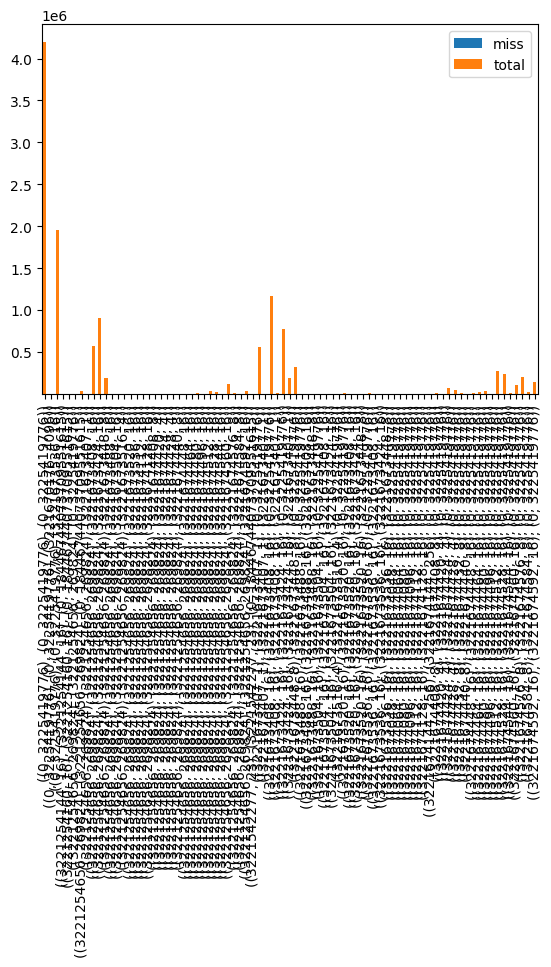

In [111]:
df.plot(kind='bar', stacked=True)

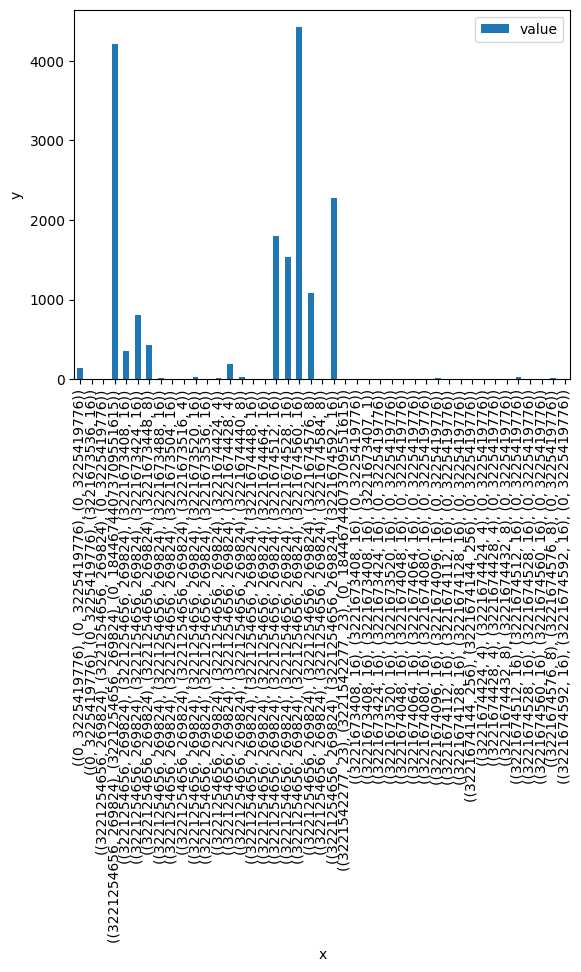

In [93]:
plot_count(backwards_analysis(data_arrivals, 3, True), "x", "y")

# Does a capability which is repeated in multiple cache lines (distringihs this) perform cluster with miss and non miss. x = number of time cache line is seen. y = miss or not

In [34]:
multiple_cache_lines = {k: len(v) for k, v in how_many_cache_lines.items()}
multiple_missess = [miss_caps[k] for k in how_many_cache_lines.keys()]
size = [k.boundsLength for k in how_many_cache_lines.keys()]

In [37]:
df = pd.DataFrame(data={"Cap": multiple_cache_lines.keys(), "Count": multiple_cache_lines.values(), "miss_count": multiple_missess, "size":size})
df = df.sort_values("size")
df

,Cap,Count,miss_count,size
50,Cap virtBase 3221673407 length 1 offset 0,5,0,1
51,Cap virtBase 3221673516 length 4 offset 0,3,0,4
23,Cap virtBase 3221674420 length 4 offset 0,4,0,4
22,Cap virtBase 3221674424 length 4 offset 0,4,3,4
21,Cap virtBase 3221674428 length 4 offset 0,4,3,4
...,...,...,...,...
165142,Cap virtBase 0 length 36893488147419103231 off...,3,0,36893488147419103231
165143,Cap virtBase 0 length 36893488147419103231 off...,3,0,36893488147419103231
165144,Cap virtBase 0 length 36893488147419103231 off...,2,0,36893488147419103231
36,Cap virtBase 0 length 36893488147419103231 off...,3,0,36893488147419103231


In [36]:
df.plot(kind="bar", x="size",y="Count")

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7f2cf669e280> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7f2bcfb63280> (for post_execute):


KeyboardInterrupt: 

# Number of different capabilites for each size.

In [38]:
size_virt_set

defaultdict(set,
            {16: {3221254144,
              3221254160,
              3221542406,
              3221673408,
              3221673424,
              3221673456,
              3221673472,
              3221673488,
              3221673504,
              3221673520,
              3221673536,
              3221674048,
              3221674064,
              3221674080,
              3221674096,
              3221674112,
              3221674128,
              3221674448,
              3221674464,
              3221674480,
              3221674496,
              3221674512,
              3221674528,
              3221674544,
              3221674560,
              3221674592},
             80: {3221543512},
             37: {3221542240, 3221542300},
             36893488147419103231: {0},
             7: {3221542337},
             23: {3221542277},
             3225419776: {0},
             32: {1647312896},
             269824: {3221254656},
             22: {3221542344},


In [40]:
df= pd.DataFrame.from_dict({k:[len(v)] for k, v in size_virt_set.items()}).transpose()
df = df.sort_index()
df

,0
1,1
4,4
7,1
8,7
16,26
22,1
23,1
32,1
37,2
80,1


<Axes: xlabel='Capability size', ylabel='Number of unique capabilites'>

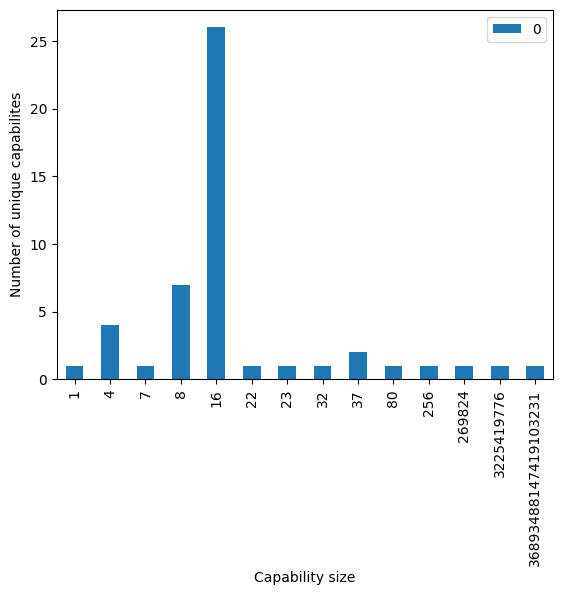

In [41]:
df.plot(kind="bar", xlabel="Capability size", ylabel="Number of unique capabilites")

# Number of misses for each size

In [44]:
sum(size_miss.values())

17688

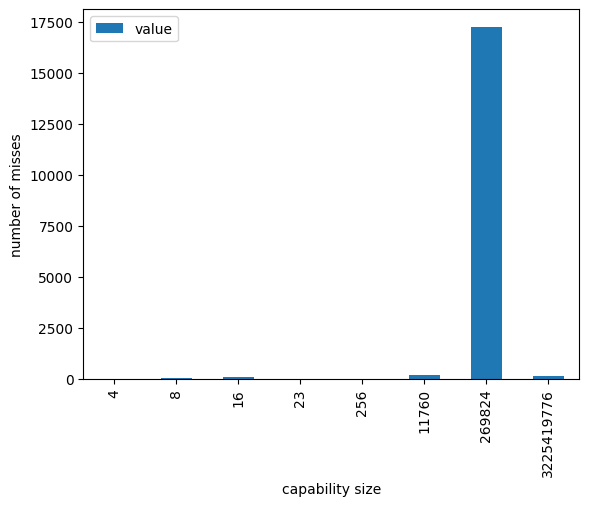

In [45]:
plot_count(size_miss, "capability size", "number of misses")

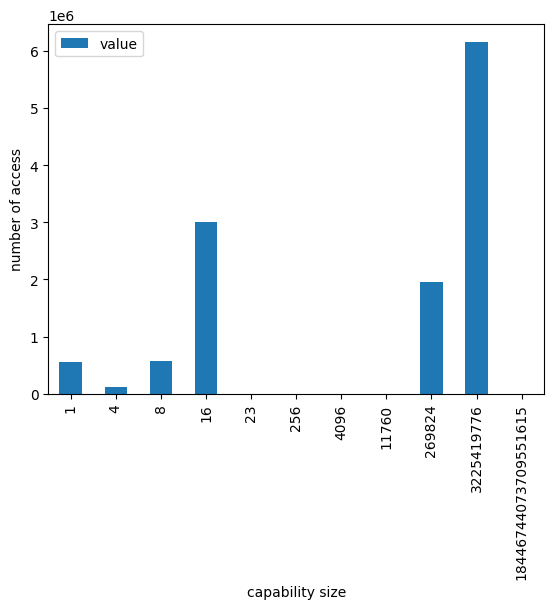

In [46]:
plot_count(size_access, "capability size", "number of access")

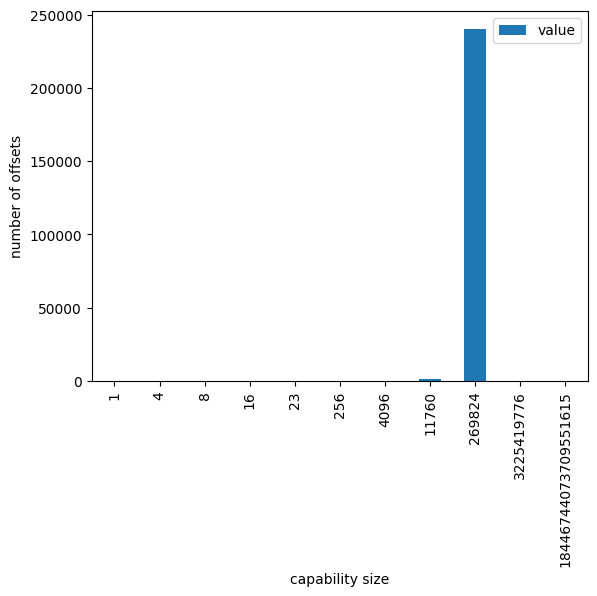

In [47]:
plot_count(set_dict_to_count(offsets_access_size), "capability size", "number of offsets")

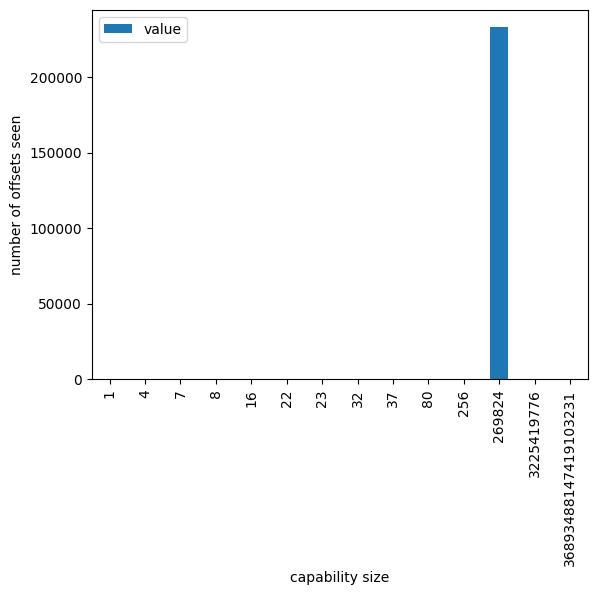

In [48]:
plot_count(set_dict_to_count(offsets_seen_size), "capability size", "number of offsets seen")

In [14]:
class SizePrefetcher:
    def __init__(self):
        self.miss_count = defaultdict(int)
        self.total_count = defaultdict(int)
        self.correctly_predicted = 0
    
    def reportDataArrival(self, reportDataArrival: ReportDataArrival):
        if reportDataArrival.wasMiss:
            self.miss_count[reportDataArrival.requestCap.boundsLength] += 1

        self.total_count[reportDataArrival.cap1.boundsLength] += 1
        self.total_count[reportDataArrival.cap2.boundsLength] += 1
        self.total_count[reportDataArrival.cap3.boundsLength] += 1
        self.total_count[reportDataArrival.cap4.boundsLength] += 1

    def __str__(self):
        return str(self.miss_count) + str(self.total_count)


# class SizeOffsetPrefetcher:
#     sizeoffsetmap = {}
#     def reportAccess(self, reportAccess):

#         reportAccess
# We want to take in reportAccess, reportDataArrival, generatePrefetech, check if prefetcher is correct, take in misses 

In [ ]:
!tail 